### **Autor**: David Roca Tauste

---
---
# EJERCICIOS FINALES TEMA 3
---
---

### **EJERCICIO 4: El EJEMPLO 3 quizás tenga aun error de cálculo. Te propongo que hagas un programa en Python que realice los cálculos.**

### Realmente es `EJEMPLO 2`

In [ ]:
a = set([1, 3, 5])
b = set([4, 5, 6])

numeros_totales = 6

p_a = len(a) / numeros_totales  # => 0.5
p_b = len(b) / numeros_totales  # => 0.5
p_a_Y_b = len(a & b) / numeros_totales  # => 0.166
p_a_O_b = len(a | b) / numeros_totales  # => 0.833
p_a_condi_b = p_a_Y_b / p_b  # => 0.33

print("P(a)=", p_a)
print("P(b)=", p_b)
print("P(a Y b)=", p_a_Y_b)
print("P(a O b)=", p_a_O_b)

print("P(a | b)=", p_a_condi_b)  # => 0.33

P(a)= 0.5
P(b)= 0.5
P(a Y b) 0.16666666666666666
P(a O b)= 0.8333333333333334
P(a | b)= 0.3333333333333333


---
### **EJERCICIO 5. Calcula la probabilidad de que en el EJEMPLO 5, el correo con las palabras “lunch money money” sea spam o normal:**

### Realmente es `EJEMPLO 8`

### a) Justo antes de añadir el contador extra (enlace: cuando hay 8 correos normales con 17 palabras en normal y 4 correos spam con 7 palabras en spam)
**Datos:**<br>
L(lunch|normal) = 0.17<br>
L(lunch|spam) = 0<br>

L(money|normal) = 0.058<br>
L(money|spam) = 0.57<br>

**Cálculos**:<br>
W = conjunto de palabras en el correo: lunch, money, money

- Probabilidad de que sea `spam`:
P(W|spam) = P(lunch|spam) x P(money|spam) x P(money|spam) = 0 x 0'57 x 0'57 = `0`%

- Probabilidad de que sea `normal`:
P(W|normal) = P(lunch|normal) x P(money|normal) x P(money|normal) = 0'17 x 0'58 x 0'58 = `0'00057`%


### b) Justo después de añadir un contador fijo para evitar el cero a cada palabra.
**Datos:**<br>
L(lunch|normal) = 4/21 = 0.19<br>
L(lunch|spam) = 1/11 = 0.09<br>

L(money|normal) = 2/21 = 0.09<br>
L(money|spam) = 5/11 = 0.45<br>

**Cálculos**:<br>
- Probabilidad de que sea `spam`:
P(W|spam) = P(lunch|spam) x P(money|spam) x P(money|spam) = 0'09 x 0'45 x 0'45 = `0'018225`%

- Probabilidad de que sea `normal`:
P(W|normal) = P(lunch|normal) x P(money|normal) x P(money|normal) = 0'19 x 0'09 x 0'09 = `0'001539`%

---
### **EJERCICIO 6: Usando los datos del ejercicio anterior, entrena un modelo Bayesiano creado con scikit-learn. Y predice lo mismo que en el ejemplo3.**

In [19]:
from collections import defaultdict
import math

# 8 correos normales con 17 palabras en total
palabras_normal = ['lunch'] * 3 + ['money'] * 1 + ['meeting'] * 13
# 4 correos spam con 7 palabras en total
palabras_spam = ['money'] * 4 + ['win'] * 3

def contar_palabras(lista):
    conteo = defaultdict(int)
    for palabra in lista:
        conteo[palabra] += 1
    return conteo

# Contar palabras en cada clase
conteo_normal = contar_palabras(palabras_normal)
conteo_spam = contar_palabras(palabras_spam)

def calcular_verosimilitud(conteo, total, vocabulario, laplace=0):
    verosimilitud = {}
    V = len(vocabulario)
    for palabra in vocabulario:
        verosimilitud[palabra] = (conteo[palabra] + laplace) / (total + laplace * V)
    return verosimilitud

# Crear el vocabulario total
vocabulario = set(conteo_normal) | set(conteo_spam) | {'lunch', 'money'}

# Sin suavizado
verosimilitud_normal = calcular_verosimilitud(conteo_normal, sum(conteo_normal.values()), vocabulario)
verosimilitud_spam = calcular_verosimilitud(conteo_spam, sum(conteo_spam.values()), vocabulario)

# Con suavizado de Laplace
verosimilitud_normal_laplace = calcular_verosimilitud(conteo_normal, sum(conteo_normal.values()), vocabulario, laplace=1)
verosimilitud_spam_laplace = calcular_verosimilitud(conteo_spam, sum(conteo_spam.values()), vocabulario, laplace=1)

def predecir(correo, verosimilitud, priori):
    log_prob = math.log(priori)
    for palabra in correo:
        prob = verosimilitud.get(palabra, 1e-6)
        if prob != 0:
            log_prob += math.log(prob)
    return log_prob

# Probabilidades a priori
priori_normal = 8 / (8 + 4)
priori_spam = 4 / (8 + 4)

# Correo de prueba
correo_prueba = ['lunch', 'money', 'money']

# Sin suavizado
log_p_normal = predecir(correo_prueba, verosimilitud_normal, priori_normal)
log_p_spam = predecir(correo_prueba, verosimilitud_spam, priori_spam)

# Con suavizado
log_p_normal_laplace = predecir(correo_prueba, verosimilitud_normal_laplace, priori_normal)
log_p_spam_laplace = predecir(correo_prueba, verosimilitud_spam_laplace, priori_spam)

# Resultados
print("Sin suavizado:")
print("P(normal|correo) =", log_p_normal)
print("P(spam|correo) =", log_p_spam)

print("\nCon suavizado de Laplace:")
print("P(normal|correo) =", log_p_normal_laplace)
print("P(spam|correo) =", log_p_spam_laplace)

# Clasificación final
def clasificar(log_normal, log_spam):
    if log_spam > log_normal:
        return "spam"
    else:
        return "normal"

print("\nClasificación (sin suavizado):", clasificar(log_p_normal, log_p_spam))
print("Clasificación (con suavizado):", clasificar(log_p_normal_laplace, log_p_spam_laplace))

Sin suavizado:
P(normal|correo) = -7.806492851608703
P(spam|correo) = -2.2178438645389553

Con suavizado de Laplace:
P(normal|correo) = -6.766443699038652
P(spam|correo) = -5.073422282195021

Clasificación (sin suavizado): spam
Clasificación (con suavizado): spam


---
### **EJERCICIO 7. Entrena un modelo Bayesiano para los datos del EJEMPLO 4 y predice el mismo caso que en el ejemplo.**

In [5]:
# Datos de entrenamiento
datos = [
    {"weather": "Sunny",    "temp": "Hot",   "play": "No"},
    {"weather": "Sunny",    "temp": "Hot",   "play": "No"},
    {"weather": "Overcast", "temp": "Hot",   "play": "Yes"},
    {"weather": "Rainy",    "temp": "Mild",  "play": "Yes"},
    {"weather": "Rainy",    "temp": "Cool",  "play": "Yes"},
    {"weather": "Rainy",    "temp": "Cool",  "play": "No"},
    {"weather": "Overcast", "temp": "Cool",  "play": "Yes"},
    {"weather": "Sunny",    "temp": "Mild",  "play": "No"},
    {"weather": "Sunny",    "temp": "Cool",  "play": "Yes"},
    {"weather": "Rainy",    "temp": "Mild",  "play": "Yes"},
    {"weather": "Sunny",    "temp": "Mild",  "play": "Yes"},
    {"weather": "Overcast", "temp": "Mild",  "play": "Yes"},
    {"weather": "Overcast", "temp": "Hot",   "play": "Yes"},
    {"weather": "Rainy",    "temp": "Mild",  "play": "No"},
]

# Contar totales
total = len(datos)
yes_conteo = sum(1 for d in datos if d["play"] == "Yes")
no_conteo = total - yes_conteo

# Probabilidades
prob_yes = yes_conteo / total
prob_no = no_conteo / total

# Función para contar frecuencia condicional
def probabilidad_condicional(atributo, valor, etiqueta):
    etiqueta_conteo = sum(1 for d in datos if d["play"] == etiqueta)
    coincidencia = sum(1 for d in datos if d[atributo] == valor and d["play"] == etiqueta)

    return coincidencia / etiqueta_conteo if etiqueta_conteo != 0 else 0

# Condiciones: Overcast, Mild
# Probabilidades condicionales
prob_overcast_yes = probabilidad_condicional("weather", "Overcast", "Yes")
prob_mild_yes = probabilidad_condicional("temp", "Mild", "Yes")

prob_overcast_no = probabilidad_condicional("weather", "Overcast", "No")
prob_mild_no = probabilidad_condicional("temp", "Mild", "No")

# Bayes
prob_yes_bayes = prob_overcast_yes * prob_mild_yes * prob_yes
prob_no_bayes = prob_overcast_no * prob_mild_no * prob_no

# Resultado
print("P(Yes | Overcast, Mild):", round(prob_yes_bayes, 3))
print("P(No  | Overcast, Mild):", round(prob_no_bayes, 3))

print("\nSegún las condiciones (Overcast, Mild):")
if prob_yes_bayes > prob_no_bayes:
    print("SÍ se juega (Yes)")
else:
    print("NO se juega (No)")


P(Yes | Overcast, Mild): 0.127
P(No  | Overcast, Mild): 0.0

Según las condiciones (Overcast, Mild):
SÍ se juega (Yes)


---
### **EJERCICIO 8. Vamos a clasificar frases en dos categorías: Deportivas y tecnológicas. Copia el siguiente código:**

In [1]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Definir los datos
textos = [
    " El equipo ganó el partido ", " Gran jugada en la final de fútbol ",
    " El nuevo teléfono tiene una gran cámara ", " Apple lanza una nueva actualización ",
    " El tenista venció a su rival ", " Los procesadores Intel ahora son más rápidos ",
    " ram y cpu son elementos básicos del computador ", " Un sistema operativo muy exigente de recursos ",
    " la selección nacional de fútbol ha jugado un buen partido ", " han batido el record del mundo ",
    " los partidos de la nba y la ach me gustan ", " las gui necesitan una cpu potente "
]
clases = ["deporte", "tecnología"]
etiquetas = [0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1] # 0 = deporte, 1 = tecnología

# Preproceso
vectorizador = TfidfVectorizer()
X = vectorizador.fit_transform(textos) # Convertir textos en matriz de características
X_train, X_test, y_train, y_test = train_test_split(X, etiquetas, test_size=0.2, random_state=546)

# Entrenar y validar modelo
modelo = MultinomialNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Exactitud del modelo:", accuracy)

Exactitud del modelo: 0.6666666666666666


### a) ¿Por qué usamos MultinomialNB y no GaussianNB?
Utilizamos MultinomialNB porque los datos son discretos y no negativos.

GaussianNB es mejor utilizarlo cuando los datos son continuos y, además, siguen una distribución normal.


### b) Modifica el código para usar tu semilla aleatoria y añade código al final de manera pregunte repetidamente por una frase hasta que la frase esté vacía y haga la predicción de a qué clase pertenece (deporte o tecnología) mostrando las probabilidades calculadas.

## `DESCOMENTAR`

In [ ]:
print("\nIntroduce frases para clasificar. Pulsa Enter sin escribir nada para salir.\n")
"""
while True:
    frase = input("Frase: ").strip()
    if frase == "":
        print("Fin de la clasificación.")
        break

    X_input = vectorizador.transform([frase])
    pred = modelo.predict(X_input)[0]
    proba = modelo.predict_proba(X_input)[0]

    categoria = "Deportiva" if pred == 0 else "Tecnológica"
    print(f"Categoría: {categoria}")
    print(f" - Frase: {frase}")
    print(f" - Probabilidades -> Deportiva: {proba[0]:.4f}, Tecnológica: {proba[1]:.4f}\n")
"""


Introduce frases para clasificar. Pulsa Enter sin escribir nada para salir.

Categoría: Deportiva
 - Frase: fútbol
 - Probabilidades -> Deportiva: 0.6686, Tecnológica: 0.3314

Categoría: Deportiva
 - Frase: messi
 - Probabilidades -> Deportiva: 0.5556, Tecnológica: 0.4444

Categoría: Deportiva
 - Frase: tenis tenis
 - Probabilidades -> Deportiva: 0.5556, Tecnológica: 0.4444

Categoría: Deportiva
 - Frase: ordenador
 - Probabilidades -> Deportiva: 0.5556, Tecnológica: 0.4444

Categoría: Deportiva
 - Frase: ratón
 - Probabilidades -> Deportiva: 0.5556, Tecnológica: 0.4444

Categoría: Deportiva
 - Frase: fútbol
 - Probabilidades -> Deportiva: 0.6686, Tecnológica: 0.3314

Categoría: Deportiva
 - Frase: fútbol fútbol fútbol
 - Probabilidades -> Deportiva: 0.6686, Tecnológica: 0.3314

Fin de la clasificación.


---
### **EJERCICIO 9: Copia el siguiente código que define 100 muestras de peso y altura de 5 hombres y 50 mujeres, luego implementa y entrena un clasificador de tipo GaussianNB (naïve Bayes gausiano), lo valida y dibuja los datos usados y lo testea mostrando su desempeño.**

Precisión del modelo: 0.9333333333333333


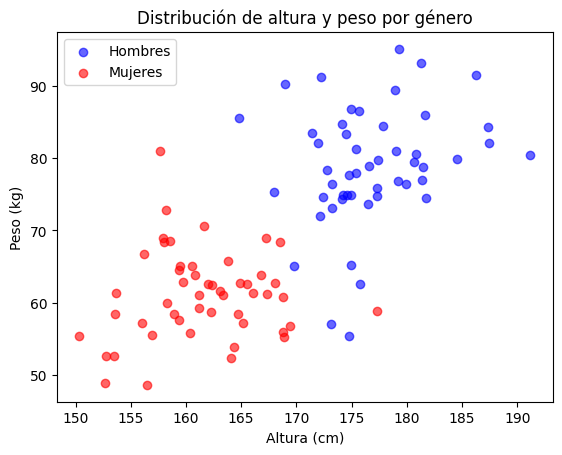

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

np.random.seed(546)

# Generamos datos: altura (cm) peso (kg) de 50 hombres (clase 0) y mujeres (clase 1)
altura_hombres = np.random.normal(loc=175, scale=6, size=50)
peso_hombres = np.random.normal(loc=78, scale=8, size=50)
altura_mujeres = np.random.normal(loc=162, scale=5, size=50)
peso_mujeres = np.random.normal(loc=60, scale=6, size=50)
X = np.vstack(
    (
        np.column_stack((altura_hombres, peso_hombres)),
        np.column_stack((altura_mujeres, peso_mujeres)),
    )
)
y = np.array([0] * 50 + [1] * 50)  # 0 = Hombre, 1 = Mujer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=546
)

# Entrenar y validar el modelo
modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)

plt.scatter(altura_hombres, peso_hombres, label="Hombres", color="blue", alpha=0.6)
plt.scatter(altura_mujeres, peso_mujeres, label="Mujeres", color="red", alpha=0.6)
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.legend()
plt.title("Distribución de altura y peso por género")
plt.show()

### a) Modifica el código y personaliza los procesos aleatorios con tu semilla aleatoria (líneas 7 y 16). Luego añade código para que pregunte repetidamente (hasta que se indique un peso 0) un peso y una altura e indique si corresponden a un hombre o a una mujer.

## `DESCOMENTAR`

In [ ]:
"""
while True:
    try:
        peso = float(input("Introduce el peso en kg (0 para salir): "))
        if peso == 0:
            print("Fin del programa.")
            break

        altura = float(input("Introduce la altura en cm: "))
        prediccion = modelo.predict([[altura, peso]])[0]
        genero = "Hombre" if prediccion == 0 else "Mujer"
        print(f"Predicción: {genero}\n")

    except ValueError:
        print("Por favor, introduce valores numéricos válidos.\n")
"""

Predicción: Hombre

Predicción: Mujer

Predicción: Hombre

Predicción: Mujer

Predicción: Hombre

Predicción: Mujer

Predicción: Mujer

Predicción: Hombre

Fin del programa.


### b) ¿Porqué hemos escogido el GaussianNB en vez de por ejemplo el el MultinomialNB?



---
### **EJERCICIO 10. Responde a estas cuestiones sobre las máquinas de vector soporte.**

## `COMPROBAR`

### 1. ¿La idea fundamental en que se basa las Support Vector Machines?
Separar las clases encontrando el hiperplano que maximiza el margen entre los datos de distintas clases.

### 2. ¿Qué es un vector soporte?
Son los puntos de entrenamiento más cercanos al hiperplano; definen el margen y determinan la posición del hiperplano.

### 3. ¿Porqué es importante escalar las entradas al usar SVM?
Porque las SVM son sensibles a la escala de los datos: una característica con valores grandes puede dominar el cálculo del margen.

### 4. ¿Un clasificador SVM puede devolver un score de confidencia cuando clasifica una instancia? ¿Y una probabilidad?
Sí, puede dar un score de decisión (distancia al hiperplano). También puede dar probabilidades si se activa probability=True al entrenar, aunque esto hace el entrenamiento más lento.

### 5. ¿Deberías usar la versión única o la dual de una SVM para entrenar un modelo con millones de instancias y miles de características? ¿Cuál sería el modelo a elegir en scikit?
Con muchos datos (más instancias que características), es mejor la versión primal (única). En scikit-learn, el modelo adecuado es LinearSVC, no SVC.

### 6. Imagina que entrenas un clasificador SVM con kernel RBF. Compruebas que tiene underfitting con el set train ¿Debes incrementar o decrementar γ (gamma)? ¿Y C?
Debes incrementar γ y/o C.
- Mayor γ hace que el modelo sea más flexible (menos underfitting).
- Mayor C permite menos errores, ajustándose más a los datos.

---
### **EJERCICIO 11: ejecuta el código del ejemplo 20 e indica la consecuencia de:**
### a) Subir de valor el parámetro gamma del detector de outliers.
### b) Bajar el valor del parámetro gamma del detector de outliers.

---
### **EJERCICIO 12: Usa el enlace del ejemplo que compara las clases linear.SGDOneClassSVM y svm.OneClassSVM y usando uno de los métodos más sencillos de detección de outliers que vimos en la unidad 1, analiza los resultados y saca conclusiones de cada método.**

---
### **EJERCICIO 13: Copia el siguiente código que define unos datos para realizar clasificaciones en 2 clases y crea, entrena y valida un clasificador de tipo SVC.**

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generar datos (2 clases)
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_classes=2,
    n_clusters_per_class=1,
    n_redundant=0,
    random_state=546,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=546
)

# Entrenar un SVM con underfitting (C bajo, gamma bajo)
svm_under = SVC(kernel="rbf", C=0.1, gamma=0.01)
svm_under.fit(X_train, y_train)

# Predecir y evaluar
train_acc_under = accuracy_score(y_train, svm_under.predict(X_train))
test_acc_under = accuracy_score(y_test, svm_under.predict(X_test))
print(
    f"SVM Underfitting - Accuracy Train: {train_acc_under:.3f}, Test: {test_acc_under:.3f}"
)

SVM Underfitting - Accuracy Train: 0.829, Test: 0.744


### a) Modifica el código y personaliza la semilla de procesos aleatorios (líneaas 10 y 11). Lo ejecutas y muestra el accuracy que se consigue en train y test e indica el % de underfitting que tienes: (score_train - score_test) / score_train * 100
### b) Añade esta función que colorea y dibuja las fronteras de decisión y representa los datos de entrenamiento y destaca los vectores soporte.

In [29]:
def plot_frontera_decision(modelo, X, y):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
                         np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100))

    Z = modelo.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar frontera de decisión, datos y vectores soporte
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=['blue', 'black', 'red'])
    plt.contour(xx, yy, Z, levels=[-1], colors='red', linestyles='dashed')
    plt.contour(xx, yy, Z, levels=[1], colors='blue', linestyles='dashed')

    X_0 = X[y == 0]
    X_1 = X[y == 1]

    plt.scatter(X_0[:, 0], X_0[:, 1], color='green', edgecolors='k', label='Clase 0')
    plt.scatter(X_1[:, 0], X_1[:, 1], color='red', edgecolors='k', label='Clase 1')

    plt.scatter(modelo.support_vectors_[:, 0], modelo.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='k', linewidths=1.1, label="Vectores Soporte")

    plt.legend()
    titulo = f"SVC (C={modelo.C}, gamma={modelo.gamma})"
    plt.title(titulo)
    plt.show()

### c) Ahora en una nueva celda del notebook crea y entrena con los mismos datos un nuevo SVC cambiando el valor de los hiperparámetros C y gamma que consigan bajar el porcentaje de underfitting por debajo del 2%. Muestra el gráfico y los valores de accuracy como en el caso anterior que se realizaría:

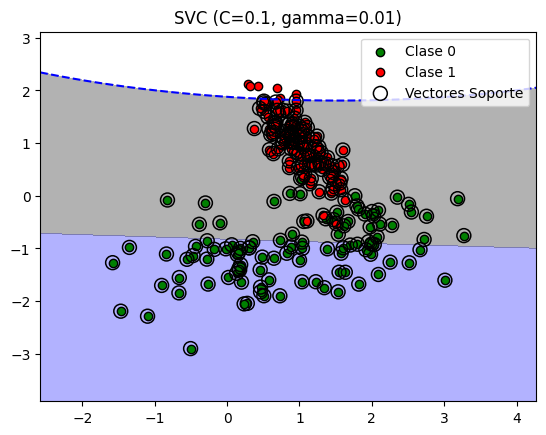

In [30]:
# Gráfica del modelo con underfitting
plot_frontera_decision(svm_under, X_train, y_train)

---
### **EJERCICIO 14. Responde a estas preguntas sobre los árboles de decisión.**

### 1. ¿Cuál podría ser aproximadamente la profundidad de un árbol de decisión entrenado sin restricciones usando un conjunto de entrenamiento de un millón de muestras?
Podría ser de alrededor de 20 a 25 niveles de profundidad, aunque puede variar dependiendo de los datos, ya que sin restricciones el árbol puede crecer mucho.

### 2. Un nodo cuando se utiliza Gini como criterio de división su nivel de impureza es normalmente más bajo o más alto que sus nodos antecesores? ¿normalmente o siempre?
La impureza de los nodos hijos normalmente es menor que la del nodo padre, pero no siempre, ya que depende de cómo se dividan los datos.

### 3. Si un árbol de decisión tiene overfitting ¿es buena idea decrementar max_depth?
Sí, reducir max_depth es una buena idea para evitar el overfitting, ya que limita la complejidad del árbol.

### 4. Un árbol de decisión tiene underfitting ¿Es buena solución escalar características?
No, escalar características no ayuda con árboles de decisión, ya que no son sensibles a la escala de los datos, por lo tanto, no soluciona el underfitting.

### 5. Si tardamos una hora en entrenar un árbol de decisión en un conjunto de datos de entrenamiento con 1 millón de muestras, ¿Cuánto tardemos aproximadamente en entrenar otro con un dataset de 100 millones de instancias?
Aproximadamente 100 veces más, es decir, cerca de 100 horas, porque el tiempo de entrenamiento crece casi linealmente con la cantidad de datos.

### 6. Si entrenas un árbol con 100 mil instancias ¿Aumentas la velocidad si indicas presort=True durante el entrenamiento?
No, con esa cantidad de datos puede hacer que el entrenamiento sea más lento. 'presort=True' es útil solo para datasets pequeños.

---
### **EJERCICIO 15. Tienes este conjunto de datos y un algoritmo de aprendizaje ID3 (utiliza la entropía como métrica) va a construir un árbol de decisión.**

### a) Consulta el algoritmo en el enlace y haz los cálculos necesarios a mano para averiguar cuál es la primera pregunta o la primera prueba que se aplicará en el nodo raíz del árbol (la mejor división). Usa este algoritmo y haz los cálculos a mano.

### b) Crea un programa en python que implemente estos pasos.

### c) Crea otro programa que use scikit a ver si obtiene resultados similares.

### d) ¿ID3 sirve para hacer regresiones?


---
### **EJERCICIO 16. En un árbol CART (utiliza Gini como métrica de impureza) se estudia dividir por dos criterios que generan las divisiones en clases que se ven en la figura:**

### a) Calcula la impureza que obtendrías si divides por la pregunta “Buena circulación?”
**Apartado izquierdo:**
Gini = 1 - (37/164)^2 - (127/164)^2 = 1 - 0'0508 - 0'6006 = 0'3486

**Apartado derecho:**
Gini = 1 - (100/133)^2 - (33/133)^2 = 1 - 0'5651 - 0'0615 = 0'3734

**Impureza:**
Gini total = 164/297 * 0'3486 + 133/297 * 0'3734 = 0'1924 + 0'1672 = **0'3596**

### b) Calcula la impureza si preguntas por “Arterias bloqueadas?”.
**Apartado izquierdo:** 0'3781

**Apartado derecho:** 0'3840

**Impureza:** **0'3814**

### c) Indica qué pregunta escogería, es decir, cuál sería la mejor división.
Escogería la división "Buena circulación" porque es la que da una menor impureza: 0'3596 vs 0'3814.

---
### **EJERCICIO 17: En el ejercicio 24, ¿porque ponemos el parámetro propability=true en el constructor del clasificador SVC que se utiliza en el método ensamblaje voting_cla?**
Porque el método de ensamblaje VotingClassifier con voting='soft' necesita que todos los clasificadores base puedan predecir probabilidades. Si no lo pusieramos, obtendríamos un error al usar VotingClassifier con voting='soft', porque intentará llamar a predict_proba() sobre un modelo que no lo soporta.

### Realmente es `EJEMPLO 37`

---
### **EJERCICIO 18: EJEMPLO DE MODELO HMM MULTINOMIAL. Un modelo con distribución categórica generan salidas (como el lanzamiento de un dado) con n_features posibles valores, es decir, son una generalización de la distribución de probabilidad de Bernoulli porque hay n_features categorías en vez de dos posibles resultados: éxito/fallo. Un HMM categórico tiene probabilidades de emisión para cada componente parametrizado por distribuciones Categóricas.**

Un modelo Multinomial genera n_trials tiradas independientes de un dado, cada una con n_features posibles valores, es decir:
- Cuando n_trials = 1 y n_features = 2, es como una distribución de Bernoulli.
- Cuando n_trials > 1 y n_features = 2, es una distribución Binomial.
- Cuando n_trials = 1 y n_features > 2, es una distribución Categórica.

Las probabilidades de emisión de cada componente de un HMM Multinomial está parametrizado por distribuciones Multinomiales.

Sospechamos que un casino está intercambiando un dado (uno o dos dados) por un dado trucado. Queremos averiguar:
1) Cuándo se utiliza el dado trucado (es decir, la ruta más probable)
2) Con qué frecuencia se utiliza el dado trucado (es decir, probabilidades de transición) y
3) Probabilidades de cada resultado en una tirada (es decir, probabilidades de emisión).

In [6]:
# Cargamos librerías
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

# Hacemos modelo generativo con 2 componentes: dado legal + dado trucado
gen_modelo = hmm.CategoricalHMM(
    n_components=2, random_state=546
)
# El primer estado es el dado legal así que comenzamos siempre con él
gen_modelo.startprob_ = np.array([1.0, 0.0])

# Ahora usamos el dado trucado:
# - Tenemos un 95 % de posibilidades de seguir usando el dado Ok y un 5 %
# - de posibilidades de cambiar al dado trucado
# - Cuando entramos en el estado del dado trucado, tenemos un 90 % de
# - posibilidades de permanecer en ese estado y un 10 % de posibilidades de salir
gen_modelo.transmat_ = np.array([[0.95, 0.05], [0.1, 0.9]])

# El primer estado(fila 0) es del dado legal: probabilidades típicas de un dado.
# El segundo (dado trucado) está sesgado hacia el 6 (lo peor en el juego)
gen_modelo.emissionprob_ = np.array(
    [
        [1 / 6, 1 / 6, 1 / 6, 1 / 6, 1 / 6, 1 / 6],
        [1 / 10, 1 / 10, 1 / 10, 1 / 10, 1 / 10, 1 / 2],
    ]
)

# simulamos 30 mil tiradas
tiradas, gen_estados = gen_modelo.sample(30000)

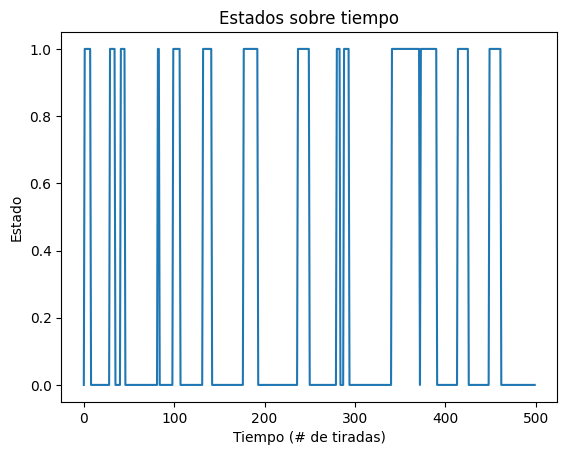

In [7]:
# Dibujamos los estados a lo largo del tiempo
fig, ax = plt.subplots()
ax.plot(gen_estados[:500])
ax.set_title("Estados sobre tiempo")
ax.set_xlabel("Tiempo (# de tiradas)")
ax.set_ylabel("Estado")
plt.show()

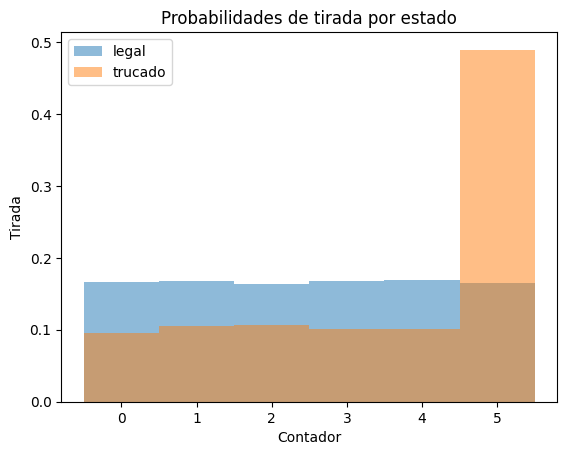

In [8]:
# Dibujamos tiradas del dado ok y del trucado
fig, ax = plt.subplots()
ax.hist(
    tiradas[gen_estados == 0],
    label="legal",
    alpha=0.5,
    bins=np.arange(7) - 0.5,
    density=True,
)
ax.hist(
    tiradas[gen_estados == 1],
    label="trucado",
    alpha=0.5,
    bins=np.arange(7) - 0.5,
    density=True,
)
ax.set_title("Probabilidades de tirada por estado")
ax.set_xlabel("Contador")
ax.set_ylabel("Tirada")
ax.legend()
plt.show()

In [9]:
# dividimos datos en train y test (50/50)
X_train = tiradas[:tiradas.shape[0] // 2]
X_test = tiradas[tiradas.shape[0] // 2:]

# Buscar un modelo con score óptimo
gen_score = gen_modelo.score(X_test)
mejor_score = mejor_modelo = None
n_entrenamientos = 50
np.random.seed(546)
for idx in range(n_entrenamientos):
    modelo1 = hmm.CategoricalHMM(n_components=2, random_state=idx, init_params='se')
    # No se inicializa la matriz de transiciones, deben dejarse aleatorias
    # porque el valor por defecto es una transición likelihood
    # sabemos que son raras (de otra forma el casino queda descubierto!)
    # así que usamos una distribución aleatoria Dirichlet a-priori con un alfa de
    # (0.1, 0.9) para forzar nuestra suposición de que las transiciones ocurren un 10%
    modelo1.transmat_ = np.array([np.random.dirichlet([0.9, 0.1]),
                                 np.random.dirichlet([0.1, 0.9])])
    modelo1.fit(X_train)
    score = modelo1.score(X_test)
    print(f'Modelo #{idx}\tScore: {score}')
    if mejor_score is None or score > mejor_score:
        mejor_score = score
        mejor_modelo = modelo1

print(f'Score generado: {gen_score}\tmejor score: {mejor_score}')

Modelo #0	Score: -26422.9023735646
Modelo #1	Score: -26394.159025333855
Modelo #2	Score: -26432.445748529073
Modelo #3	Score: -26434.771593689595
Modelo #4	Score: -26413.462315036206
Modelo #5	Score: -26390.42350799478
Modelo #6	Score: -26422.866425982633
Modelo #7	Score: -26421.07881947744
Modelo #8	Score: -26354.43177717941
Modelo #9	Score: -26322.14568478822
Modelo #10	Score: -26422.580587101995
Modelo #11	Score: -26422.866854111875
Modelo #12	Score: -26273.571028551254
Modelo #13	Score: -26387.408188380115
Modelo #14	Score: -26433.531502616548
Modelo #15	Score: -26332.74795199796
Modelo #16	Score: -26398.54192834272
Modelo #17	Score: -26417.87544332776
Modelo #18	Score: -26411.766146119684
Modelo #19	Score: -26422.866851841023
Modelo #20	Score: -26360.338958833527
Modelo #21	Score: -26422.866848139332
Modelo #22	Score: -26422.86685095387
Modelo #23	Score: -26290.35711462319
Modelo #24	Score: -26414.344533475123
Modelo #25	Score: -26424.83911749664
Modelo #26	Score: -26348.605698720

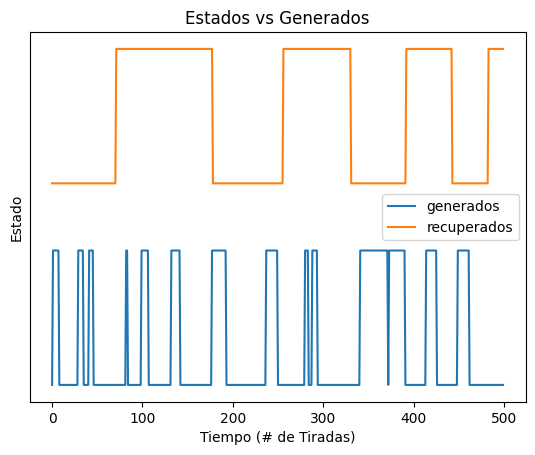

In [10]:
# Usar Viterbi para predecir secuencia de estados más probable
estados = mejor_modelo.predict(tiradas)

# Dibujar los estados recuperados comparados con los generados (primer objetivo)
fig, ax = plt.subplots()
ax.plot(gen_estados[:500], label="generados")
ax.plot(estados[:500] + 1.5, label="recuperados")
ax.set_yticks([])
ax.set_title("Estados vs Generados")
ax.set_xlabel("Tiempo (# de Tiradas)")
ax.set_ylabel("Estado")
ax.legend()
plt.show()

In [11]:
# Comprobamos transiciones aprendidas y miramos si concuerdan
print(f'Matriz de Transición Generada:\n{gen_modelo.transmat_.round(3)}\n\n'
      f'Matriz de Transición Recuperada:\n{mejor_modelo.transmat_.round(3)}\n\n')

Matriz de Transición Generada:
[[0.95 0.05]
 [0.1  0.9 ]]

Matriz de Transición Recuperada:
[[0.954 0.046]
 [0.044 0.956]]




In [12]:
# Finalmente vemos de qué forma está trucado el dado
print(f'Matriz de Emisiones Generada:\n{gen_modelo.emissionprob_.round(3)}\n\n'
      f'Matriz de Emisiones Recuperada:\n{mejor_modelo.emissionprob_.round(3)}\n\n')

Matriz de Emisiones Generada:
[[0.167 0.167 0.167 0.167 0.167 0.167]
 [0.1   0.1   0.1   0.1   0.1   0.5  ]]

Matriz de Emisiones Recuperada:
[[0.116 0.116 0.121 0.122 0.119 0.406]
 [0.168 0.177 0.165 0.174 0.174 0.142]]


